# Baseline Models

Use this notebook to build initial traditional baselines and simple uplift modeling comparisons.

In [29]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
import econml
from econml.dml import CausalForestDML
import matplotlib.pyplot as plt

In [2]:
print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("EconML:", econml.__version__)

Python: /Users/jorgemoya/micromamba/envs/cs7643-uplift/bin/python
NumPy: 1.26.4
pandas: 2.3.3
scikit-learn: 1.6.1
EconML: 0.16.0


In [3]:
RANDOM_STATE = 42

In [4]:
data_path = Path("../data/raw/hillstrom_email.csv")
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at {data_path.resolve()}"
    )

df = pd.read_csv(data_path)
print(f"Loaded {data_path.name} with shape {df.shape}")

Loaded hillstrom_email.csv with shape (64000, 12)


In [5]:
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [6]:
# We define the treatment
df["treatment"] = (df["segment"]!="No E-Mail").astype(int)

In [7]:
feature_columns = [
    "recency",
    "history_segment",
    "history",
    "mens",
    "womens",
    "zip_code",
    "newbie",
    "channel",
]

X = df[feature_columns]
T = df["treatment"]
Y = df["visit"]

In [8]:
print("X shape:", X.shape)
print("T shape:", T.shape)
print("Y shape:", Y.shape)

print("\nTreatment distribution:")
print(T.value_counts())

print("\nOutcome distribution:")
print(Y.value_counts())

X shape: (64000, 8)
T shape: (64000,)
Y shape: (64000,)

Treatment distribution:
treatment
1    42694
0    21306
Name: count, dtype: int64

Outcome distribution:
visit
0    54606
1     9394
Name: count, dtype: int64


In [9]:
visit_rate = Y.mean()

print(f"Visit rate: {visit_rate:.2%}")

Visit rate: 14.68%


In [10]:
visit_summary = (
    df
    .groupby("treatment")["visit"]
    .agg(
        customers="count",
        visit_rate="mean"
    )
)

visit_summary

,customers,visit_rate
treatment,,
0,21306,0.106167
1,42694,0.167049


In [11]:
X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
    X,
    T,
    Y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=T,
)

In [12]:
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("\nTreatment distribution (train)")
print(T_train.value_counts(normalize=True))

print("\nTreatment distribution (test)")
print(T_test.value_counts(normalize=True))

Training: (51200, 8)
Testing : (12800, 8)

Treatment distribution (train)
treatment
1    0.66709
0    0.33291
Name: proportion, dtype: float64

Treatment distribution (test)
treatment
1    0.667109
0    0.332891
Name: proportion, dtype: float64


In [13]:
categorical_features = [
    "history_segment",
    "zip_code",
    "channel",
]

numeric_features = [
    "recency",
    "history",
    "mens",
    "womens",
    "newbie",
]

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "num",
            "passthrough",
            numeric_features,
        ),
    ]
)

In [15]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [16]:
print("Training matrix:", X_train_processed.shape)
print("Testing matrix :", X_test_processed.shape)

Training matrix: (51200, 18)
Testing matrix : (12800, 18)


In [17]:
feature_names = preprocessor.get_feature_names_out()

print(f"Total features after encoding: {len(feature_names)}")
feature_names

Total features after encoding: 18


array(['cat__history_segment_1) $0 - $100',
       'cat__history_segment_2) $100 - $200',
       'cat__history_segment_3) $200 - $350',
       'cat__history_segment_4) $350 - $500',
       'cat__history_segment_5) $500 - $750',
       'cat__history_segment_6) $750 - $1,000',
       'cat__history_segment_7) $1,000 +', 'cat__zip_code_Rural',
       'cat__zip_code_Surburban', 'cat__zip_code_Urban',
       'cat__channel_Multichannel', 'cat__channel_Phone',
       'cat__channel_Web', 'num__recency', 'num__history', 'num__mens',
       'num__womens', 'num__newbie'], dtype=object)

In [19]:
causal_forest = CausalForestDML(
    model_y=RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    model_t=RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    n_estimators=500,
    min_samples_leaf=20,
    max_depth=None,
    discrete_treatment=True,
    discrete_outcome=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

In [20]:
causal_forest.fit(
    Y_train,
    T_train,
    X=X_train_processed,
)

In [23]:
test_uplift = causal_forest.effect(X_test_processed)

print("Uplift predictions shape:", test_uplift.shape)
print("Average predicted uplift:", test_uplift.mean())
print("Minimum predicted uplift:", test_uplift.min())
print("Maximum predicted uplift:", test_uplift.max())

Uplift predictions shape: (12800, 1)
Average predicted uplift: 0.062228538672552035
Minimum predicted uplift: -0.034494192414348944
Maximum predicted uplift: 0.17723647748117416


In [24]:
raw_test_ate = (Y_test[T_test==1].mean()-Y_test[T_test==0].mean())
model_test_ate = test_uplift.mean()

print(f"Raw test-set ATE:       {raw_test_ate:.4f}")
print(f"Model-estimated ATE:    {model_test_ate:.4f}")

Raw test-set ATE:       0.0601
Model-estimated ATE:    0.0622


In [25]:
uplift = causal_forest.effect(X_test_processed)

In [26]:
print(uplift.shape)

(12800, 1)


In [27]:
results = X_test.reset_index(drop=True).copy()

results["treatment"] = T_test.reset_index(drop=True)
results["visit"] = Y_test.reset_index(drop=True)
results["predicted_uplift"] = uplift

results.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,treatment,visit,predicted_uplift
0,6,5) $500 - $750,508.62,0,1,Surburban,1,Web,1,1,0.058610
1,10,4) $350 - $500,460.26,1,1,Urban,0,Phone,1,0,0.051249
2,10,1) $0 - $100,35.05,1,0,Surburban,0,Phone,1,0,0.077708
3,7,2) $100 - $200,141.74,1,0,Urban,0,Phone,1,0,0.077083
4,7,1) $0 - $100,31.30,0,1,Rural,1,Phone,1,0,0.060060


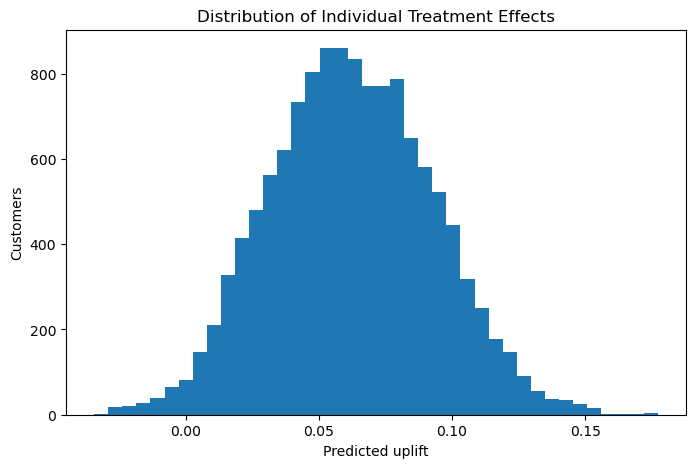

In [30]:
plt.figure(figsize=(8,5))
plt.hist(test_uplift, bins=40)
plt.xlabel("Predicted uplift")
plt.ylabel("Customers")
plt.title("Distribution of Individual Treatment Effects")
plt.show()